# StyleGAN-Inspired GAN for MNIST Digit Generation

## Problem Statement

The goal of this notebook is to build a StyleGAN-inspired image generation model that learns to generate handwritten digit images similar to those in the MNIST dataset.

StyleGAN is known for high-quality image generation, especially for faces and other complex visual domains. A full StyleGAN implementation for high-resolution images is computationally expensive, so this notebook implements a compact version suitable for Google Colab and educational use.

The model demonstrates the core StyleGAN ideas using MNIST:

- A mapping network that transforms random noise into an intermediate latent style vector.
- A learned constant input instead of directly reshaping the noise vector.
- Style modulation that controls synthesis layers.
- Noise injection that adds stochastic image variation.
- A convolutional Discriminator that learns to identify real and generated images.

## Objectives

By the end of this notebook, we will:

1. Load and preprocess the MNIST dataset.
2. Build a compact StyleGAN-inspired Generator.
3. Implement mapping, style modulation, learned constant input, and noise injection.
4. Build a convolutional Discriminator.
5. Train the model adversarially using TensorFlow and Keras.
6. Visualize generated digit images during training.
7. Understand how StyleGAN differs from earlier GAN architectures.

## Expected Outcome

After training, the Generator should produce synthetic 28x28 grayscale digit images. Since this is a compact StyleGAN-inspired implementation trained for a small number of epochs, the results may not match full StyleGAN quality, but the notebook demonstrates the architecture concepts clearly and runs in a standard Colab environment.

## 1. Import Required Libraries

This notebook uses TensorFlow/Keras, NumPy, and Matplotlib. These libraries are available in Google Colab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

# Make the experiment reproducible as much as possible.
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and Preprocess the Dataset

We use the MNIST dataset, which contains 28x28 grayscale images of handwritten digits.

The Generator uses `tanh` in its final layer, so real images are scaled to the range `[-1, 1]`.

In [2]:
# Load MNIST images. Labels are not needed for this unconditional generation task.
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Convert images to float32 for neural network training.
x_train = x_train.astype("float32")

# Scale pixel values from [0, 255] to [-1, 1].
x_train = (x_train - 127.5) / 127.5

# Add a channel dimension: (samples, height, width, channels).
x_train = np.expand_dims(x_train, axis=-1)

print("Training data shape:", x_train.shape)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


## 3. Define Hyperparameters

The latent vector `z` is transformed into an intermediate style vector `w` by the mapping network. The style vector then controls synthesis layers in the Generator.

In [3]:
# Size of the input random noise vector.
LATENT_DIM = 128

# Size of the intermediate style vector produced by the mapping network.
STYLE_DIM = 128

# Number of images processed in each training step.
BATCH_SIZE = 128

# Number of full passes through the dataset.
EPOCHS = 10

# Optimizer settings commonly used in GAN training.
LEARNING_RATE = 0.0002
BETA_1 = 0.5

# Number of generated examples to display.
NUM_EXAMPLES_TO_GENERATE = 16

## 4. Define StyleGAN-Inspired Custom Layers

This compact implementation uses two custom layers:

- `NoiseInjection`: adds learned per-channel random noise to feature maps.
- `StyleModulation`: uses the style vector to scale and shift feature maps.

These layers demonstrate the main mechanism by which StyleGAN controls image synthesis.

In [4]:
class NoiseInjection(layers.Layer):
    """Adds learned per-channel noise to feature maps."""

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.weight = self.add_weight(
            name="noise_weight",
            shape=(1, 1, 1, channels),
            initializer="zeros",
            trainable=True,
        )

    def call(self, inputs, training=False):
        batch_size = tf.shape(inputs)[0]
        height = tf.shape(inputs)[1]
        width = tf.shape(inputs)[2]
        noise = tf.random.normal([batch_size, height, width, 1])
        return inputs + self.weight * noise


class StyleModulation(layers.Layer):
    """Applies style-based scale and shift to feature maps."""

    def __init__(self, channels, style_dim, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.style_dim = style_dim
        self.style_dense = layers.Dense(channels * 2)

    def call(self, inputs):
        feature_map, style_vector = inputs
        style = self.style_dense(style_vector)
        scale, shift = tf.split(style, num_or_size_splits=2, axis=-1)
        scale = tf.reshape(scale, [-1, 1, 1, self.channels])
        shift = tf.reshape(shift, [-1, 1, 1, self.channels])
        return feature_map * (scale + 1.0) + shift

## 5. Build the Mapping Network

The mapping network transforms the original latent vector `z` into an intermediate latent vector `w`. This separates the input noise distribution from the style controls used by the synthesis network.

In [5]:
def build_mapping_network(latent_dim, style_dim):
    """Builds a compact StyleGAN mapping network."""
    inputs = layers.Input(shape=(latent_dim,), name="z_input")

    x = layers.Dense(style_dim)(inputs)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Dense(style_dim)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Dense(style_dim)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    return models.Model(inputs, x, name="Mapping_Network")


mapping_network = build_mapping_network(LATENT_DIM, STYLE_DIM)
mapping_network.summary()

Model: "Mapping_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_input (InputLayer)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,536 (193.50 KB)

 Trainable params: 49,536 (193.50 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Build the StyleGAN-Inspired Generator

Instead of reshaping the latent vector directly into an image, this Generator starts from a learned constant tensor. The style vector controls the synthesis process through style modulation layers.

In [6]:
class LearnedConstant(layers.Layer):
    """Creates a learned constant input for the synthesis network."""

    def __init__(self, height, width, channels, **kwargs):
        super().__init__(**kwargs)
        self.height = height
        self.width = width
        self.channels = channels

    def build(self, input_shape):
        self.constant = self.add_weight(
            name="learned_constant",
            shape=(1, self.height, self.width, self.channels),
            initializer="random_normal",
            trainable=True,
        )

    def call(self, style_vector):
        batch_size = tf.shape(style_vector)[0]
        return tf.tile(self.constant, [batch_size, 1, 1, 1])


def synthesis_block(x, style_vector, filters, style_dim, upsample, name):
    """Applies one compact StyleGAN-inspired synthesis block."""
    if upsample:
        x = layers.UpSampling2D(size=(2, 2), interpolation="nearest", name=f"{name}_upsample")(x)

    x = layers.Conv2D(filters, kernel_size=3, padding="same", name=f"{name}_conv")(x)
    x = NoiseInjection(name=f"{name}_noise")(x)
    x = layers.LeakyReLU(negative_slope=0.2, name=f"{name}_activation")(x)
    x = StyleModulation(filters, style_dim, name=f"{name}_style")([x, style_vector])
    return x


def build_generator(latent_dim, style_dim):
    """Builds a compact StyleGAN-inspired Generator for 28x28 images."""
    z_input = layers.Input(shape=(latent_dim,), name="z_input")

    # Convert z into the intermediate style vector w.
    style_vector = mapping_network(z_input)

    # Start synthesis from a learned 7x7 constant feature map.
    x = LearnedConstant(7, 7, 128, name="learned_constant_input")(style_vector)

    # Synthesis blocks progressively build image features.
    x = synthesis_block(x, style_vector, 128, style_dim, upsample=False, name="block_7x7")
    x = synthesis_block(x, style_vector, 64, style_dim, upsample=True, name="block_14x14")
    x = synthesis_block(x, style_vector, 32, style_dim, upsample=True, name="block_28x28")

    # Convert features to a single-channel grayscale image in [-1, 1].
    image_output = layers.Conv2D(1, kernel_size=1, padding="same", activation="tanh", name="to_image")(x)

    return models.Model(z_input, image_output, name="StyleGAN_Inspired_Generator")


generator = build_generator(LATENT_DIM, STYLE_DIM)
generator.summary()

Model: "StyleGAN_Inspired_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z_input             │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Mapping_Network     │ (None, 128)       │     49,536 │ z_input[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learned_constant_i… │ (None, 7, 7, 128) │      6,272 │ Mapping_Network[… │
│ (LearnedConstant)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_7x7_conv      │ (None, 7, 7, 128) │    147,584 │ learned_constant… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_7x7_noise     │ (None, 7, 7, 128) │        128 │ block_7x7_conv[0… │
│ (NoiseInjection)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_7x7_activati… │ (None, 7, 7, 128) │          0 │ block_7x7_noise[… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_7x7_style     │ (None, 7, 7, 128) │     33,024 │ block_7x7_activa… │
│ (StyleModulation)   │                   │            │ Mapping_Network[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_14x14_upsamp… │ (None, 14, 14,    │          0 │ block_7x7_style[… │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_14x14_conv    │ (None, 14, 14,    │     73,792 │ block_14x14_upsa… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_14x14_noise   │ (None, 14, 14,    │         64 │ block_14x14_conv… │
│ (NoiseInjection)    │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_14x14_activa… │ (None, 14, 14,    │          0 │ block_14x14_nois… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_14x14_style   │ (None, 14, 14,    │     16,512 │ block_14x14_acti… │
│ (StyleModulation)   │ 64)               │            │ Mapping_Network[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_28x28_upsamp… │ (None, 28, 28,    │          0 │ block_14x14_styl… │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_28x28_conv    │ (None, 28, 28,    │     18,464 │ block_28x28_upsa… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_28x28_noise   │ (None, 28, 28,    │         32 │ block_28x28_conv… │
│ (NoiseInjection)    │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_28x28_activa… │ (None, 28, 28,    │          0 │ block_28x28_nois… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_28x28_style   │ (None, 28, 28,    │      8,256 │ block_28x28_acti

 Total params: 353,697 (1.35 MB)

 Trainable params: 353,697 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Build the Discriminator

The Discriminator receives a 28x28 grayscale image and predicts whether it is real or generated. This compact convolutional Discriminator is suitable for MNIST-sized images.

In [7]:
def build_discriminator():
    """Builds a convolutional Discriminator."""
    model = models.Sequential(name="Discriminator")

    model.add(layers.Input(shape=(28, 28, 1)))

    model.add(layers.Conv2D(64, kernel_size=4, strides=2, padding="same"))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, kernel_size=4, strides=2, padding="same"))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))

    return model


discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,561 (541.25 KB)

 Trainable params: 138,561 (541.25 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Configure Loss Functions and Optimizers

The Discriminator learns to classify real images as real and generated images as fake. The Generator learns to create images that the Discriminator classifies as real.

In [8]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)


def discriminator_loss(real_output, fake_output):
    """Calculates Discriminator loss for real and generated images."""
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss


def generator_loss(fake_output):
    """Calculates Generator loss based on fooling the Discriminator."""
    return cross_entropy(tf.ones_like(fake_output), fake_output)

## 9. Prepare the Training Dataset

The TensorFlow Dataset API is used to shuffle, batch, and prefetch the training images efficiently.

In [9]:
train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(buffer_size=x_train.shape[0])
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Number of batches per epoch:", tf.data.experimental.cardinality(train_dataset).numpy())

Number of batches per epoch: 468


## 10. Define the Training Step

Each training step updates both models:

1. The Generator creates synthetic images from random latent vectors.
2. The Discriminator evaluates real and generated images.
3. The Discriminator is updated to improve real/fake classification.
4. The Generator is updated to produce more realistic images.

In [10]:
@tf.function
def train_step(real_images):
    """Runs one adversarial training step."""
    batch_size = tf.shape(real_images)[0]
    z = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(z, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

## 11. Helper Function to Display Generated Images

A fixed set of latent vectors is used so image progress can be compared across epochs.

In [11]:
seed_z = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])


def display_generated_images(model, epoch, test_input):
    """Displays a grid of generated images."""
    predictions = model(test_input, training=False)

    # Convert generated images from [-1, 1] to [0, 1] for plotting.
    predictions = (predictions + 1.0) / 2.0

    plt.figure(figsize=(6, 6))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle(f"StyleGAN-Inspired Generated Images After Epoch {epoch}")
    plt.tight_layout()
    plt.show()

## 12. Train the StyleGAN-Inspired Model

GAN losses may fluctuate because the Generator and Discriminator are trained against each other. Generated image quality should be reviewed visually in addition to monitoring losses.

Epoch 01/10 | Generator Loss: 0.9395 | Discriminator Loss: 1.1208


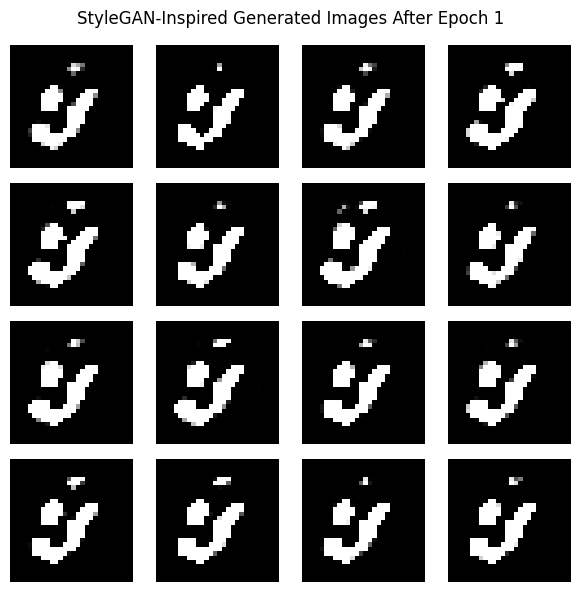

Epoch 02/10 | Generator Loss: 1.0725 | Discriminator Loss: 1.0841
Epoch 03/10 | Generator Loss: 0.9274 | Discriminator Loss: 1.1604
Epoch 04/10 | Generator Loss: 1.0491 | Discriminator Loss: 1.0945
Epoch 05/10 | Generator Loss: 1.1837 | Discriminator Loss: 0.9901


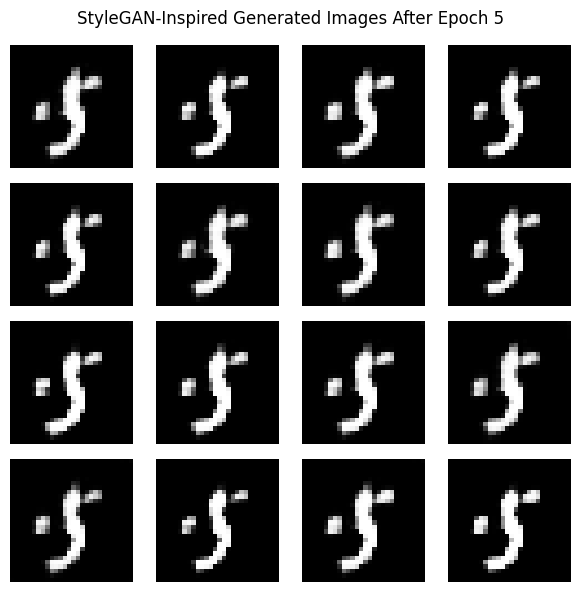

Epoch 06/10 | Generator Loss: 1.1743 | Discriminator Loss: 1.0415
Epoch 07/10 | Generator Loss: 1.2222 | Discriminator Loss: 0.9746
Epoch 08/10 | Generator Loss: 1.4550 | Discriminator Loss: 0.8269
Epoch 09/10 | Generator Loss: 1.4081 | Discriminator Loss: 0.8684
Epoch 10/10 | Generator Loss: 1.3862 | Discriminator Loss: 0.8874


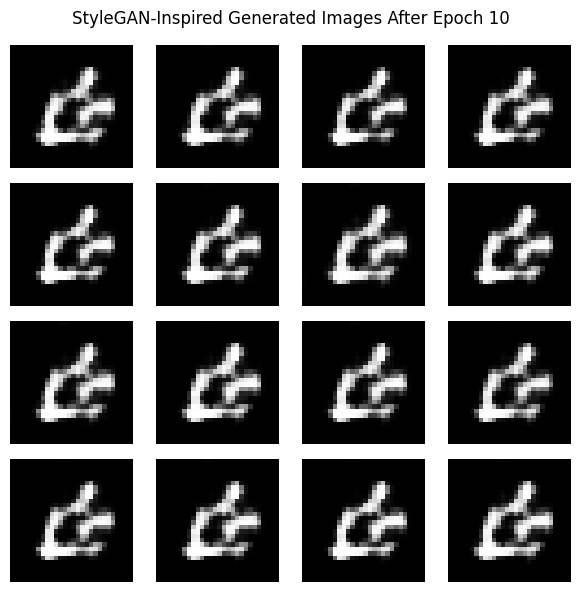

In [12]:
def train(dataset, epochs):
    """Trains the StyleGAN-inspired model and displays generated samples."""
    generator_losses = []
    discriminator_losses = []

    for epoch in range(1, epochs + 1):
        epoch_gen_losses = []
        epoch_disc_losses = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_losses.append(gen_loss.numpy())
            epoch_disc_losses.append(disc_loss.numpy())

        avg_gen_loss = float(np.mean(epoch_gen_losses))
        avg_disc_loss = float(np.mean(epoch_disc_losses))
        generator_losses.append(avg_gen_loss)
        discriminator_losses.append(avg_disc_loss)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Generator Loss: {avg_gen_loss:.4f} | "
            f"Discriminator Loss: {avg_disc_loss:.4f}"
        )

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            display_generated_images(generator, epoch, seed_z)

    return generator_losses, discriminator_losses


generator_losses, discriminator_losses = train(train_dataset, EPOCHS)

## 13. Plot Training Losses

The loss curves help monitor training behavior. In GANs, visual sample quality is usually more important than expecting perfectly smooth loss curves.

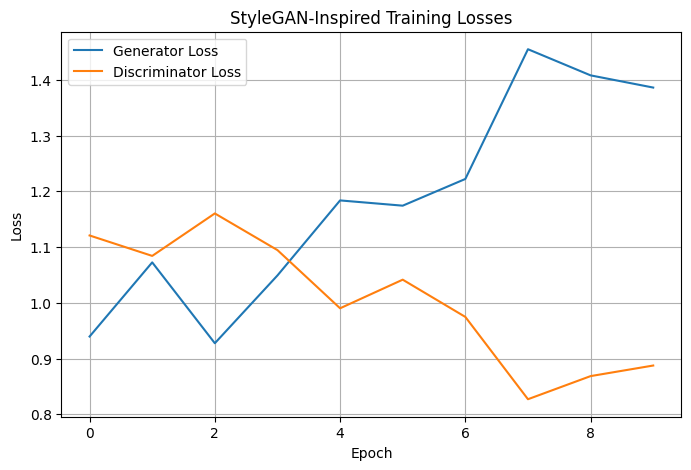

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("StyleGAN-Inspired Training Losses")
plt.legend()
plt.grid(True)
plt.show()

## 14. Generate Final Synthetic Images

The trained Generator can create new handwritten digit images from fresh random latent vectors.

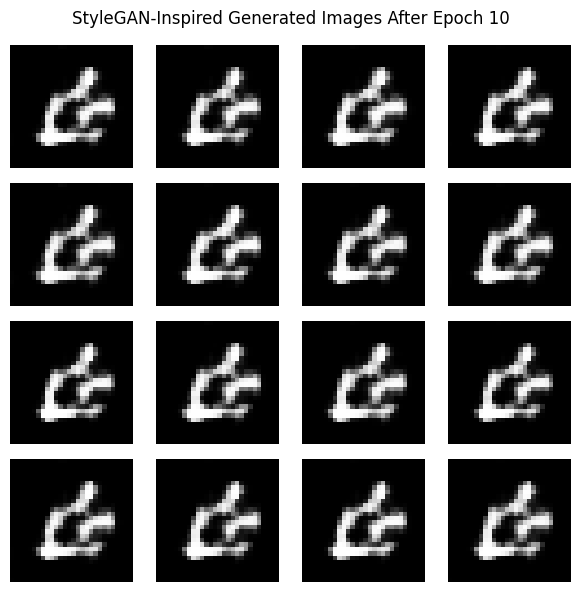

In [14]:
new_z = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])
display_generated_images(generator, EPOCHS, new_z)

## 15. Explore Style Interpolation

A useful StyleGAN concept is smooth interpolation through latent space. The following cell interpolates between two latent vectors and generates images along the path.

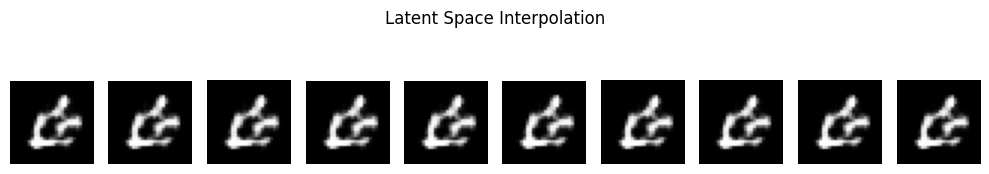

In [15]:
def show_latent_interpolation(model, steps=10):
    """Displays generated images along a linear interpolation between two latent vectors."""
    z_start = tf.random.normal([1, LATENT_DIM])
    z_end = tf.random.normal([1, LATENT_DIM])

    interpolation_values = tf.linspace(0.0, 1.0, steps)
    interpolated_z = []

    for alpha in interpolation_values:
        interpolated_z.append((1.0 - alpha) * z_start + alpha * z_end)

    interpolated_z = tf.concat(interpolated_z, axis=0)
    generated_images = model(interpolated_z, training=False)
    generated_images = (generated_images + 1.0) / 2.0

    plt.figure(figsize=(10, 2))
    for i in range(steps):
        plt.subplot(1, steps, i + 1)
        plt.imshow(generated_images[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle("Latent Space Interpolation")
    plt.tight_layout()
    plt.show()


show_latent_interpolation(generator)

## Conclusion

This notebook implemented a compact StyleGAN-inspired model for MNIST digit generation. The Generator used a mapping network, learned constant input, style modulation, and noise injection to demonstrate the key architectural ideas behind StyleGAN.

Unlike earlier GANs that feed random noise directly into the Generator, StyleGAN separates latent sampling from image synthesis. This gives the model a more structured way to control generated image features.

A production-level StyleGAN system usually uses larger images, deeper synthesis networks, adaptive normalization or modulation-demodulation, path length regularization, and more advanced training strategies. This notebook provides a lightweight and runnable foundation for understanding the core concept before moving to full-scale StyleGAN implementations.